In [1]:
%cd ..

/data/current/projects/tcrio/tcrio


In [2]:
from tcr_io.operations.unconventional_tcrs import MaitHits 
from tcr_io.dataset import TcrDataset


In [3]:
ds = TcrDataset(
    "/data/current/tcrio_db/emerson_2017"
)

In [4]:
MaitHits().run(ds)

Counting mait hits in repertoires:   0%|          | 0/786 [00:00<?, ?it/s]

Counting mait hits in repertoires: 100%|██████████| 786/786 [00:18<00:00, 41.66it/s]


OperationResults(outputs={'meta/repertoire/mait_hits.parquet': shape: (786, 6)
┌───────────────┬──────────────────┬──────────────────┬──────────────────┬─────────────┬───────────┐
│ repertoire_id ┆ total_mait_dupli ┆ median_mait_dupl ┆ mean_mait_duplic ┆ n_mait_hits ┆ breadth   │
│ ---           ┆ cates            ┆ icates           ┆ ates             ┆ ---         ┆ ---       │
│ str           ┆ ---              ┆ ---              ┆ ---              ┆ u32         ┆ f64       │
│               ┆ i64              ┆ f64              ┆ f64              ┆             ┆           │
╞═══════════════╪══════════════════╪══════════════════╪══════════════════╪═════════════╪═══════════╡
│ Keck0001      ┆ 254              ┆ 1.0              ┆ 1.649351         ┆ 154         ┆ -6.453188 │
│ Keck0002      ┆ 472              ┆ 1.0              ┆ 3.658915         ┆ 129         ┆ -6.494277 │
│ Keck0003      ┆ 1818             ┆ 1.0              ┆ 6.247423         ┆ 291         ┆ -6.462527 │
│ Keck0004  

In [5]:
res = _

In [10]:
ds.full_patient_meta

patient_id,patient_repertoires,n_repertoires,age,sex,ethnicity,cmv_status,A,B,C,DRB1,DPA1,DPB1,DQA1,DQB1
str,list[str],i64,i64,str,str,bool,list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str]
"""Keck0001""","[""Keck0001""]",1,null,null,null,null,null,null,null,null,null,null,null,null
"""Keck0002""","[""Keck0002""]",1,null,null,null,null,null,null,null,null,null,null,null,null
"""Keck0003""","[""Keck0003""]",1,null,null,null,null,null,null,null,null,null,null,null,null
"""Keck0004""","[""Keck0004""]",1,null,null,null,null,null,null,null,null,null,null,null,null
"""Keck0005""","[""Keck0005""]",1,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P00663""","[""P00663""]",1,null,null,"""Unknown Ethnicity""",null,"[""2902"", ""0201""]","[""4403"", ""0702""]","[""1601"", ""0702""]","[""1501"", ""0701""]","[""0103""]","[""0401""]","[""0102"", ""0201""]","[""0602"", ""0202""]"
"""P00665""","[""P00665""]",1,57,"""Female""","""Unknown Ethnicity""",false,"[""0101"", ""0201""]","[""5101"", ""5701""]","[""1502"", ""0701""]","[""0901"", ""1302""]","[""0103""]","[""0401"", ""0301""]","[""0102"", ""0302""]","[""0604"", ""0303""]"
"""P00666""","[""P00666""]",1,null,null,"""Unknown Ethnicity""",null,"[""0101""]","[""1302"", ""4403""]","[""0602"", ""0401""]","[""1302"", ""0701""]","[""0201"", ""0103""]","[""0401"", ""1301""]","[""0102"", ""0201""]","[""0609"", ""0202""]"


In [21]:
table = ds.repertoire_meta.join(res.outputs["meta/repertoire/mait_hits.parquet"], on="repertoire_id", how="left").join(
    ds.full_patient_meta, on="patient_id", how="left"
)

In [22]:
import seaborn as sns

In [23]:
import polars as pl 

In [24]:
table

repertoire_id,source_files,patient_id,n_clonotypes,n_filtered_clonotypes,total_duplicates,total_mait_duplicates,median_mait_duplicates,mean_mait_duplicates,n_mait_hits,breadth,patient_repertoires,n_repertoires,age,sex,ethnicity,cmv_status,A,B,C,DRB1,DPA1,DPB1,DQA1,DQB1
str,list[str],str,i64,i64,i64,i64,f64,f64,u32,f64,list[str],i64,i64,str,str,bool,list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str]
"""Keck0001""","[""Keck0001_MC1.tsv""]","""Keck0001""",98381,9164,160828,254,1.0,1.649351,154,-6.453188,"[""Keck0001""]",1,null,null,null,null,null,null,null,null,null,null,null,null
"""Keck0002""","[""Keck0002_MC1.tsv""]","""Keck0002""",85974,8030,179817,472,1.0,3.658915,129,-6.494277,"[""Keck0002""]",1,null,null,null,null,null,null,null,null,null,null,null,null
"""Keck0003""","[""Keck0003_MC1.tsv""]","""Keck0003""",187077,12100,279447,1818,1.0,6.247423,291,-6.462527,"[""Keck0003""]",1,null,null,null,null,null,null,null,null,null,null,null,null
"""Keck0004""","[""Keck0004_MC1.tsv""]","""Keck0004""",119068,9199,185015,326,1.0,1.697917,192,-6.424768,"[""Keck0004""]",1,null,null,null,null,null,null,null,null,null,null,null,null
"""Keck0005""","[""Keck0005_MC1.tsv""]","""Keck0005""",135267,10997,189668,354,1.0,1.934426,183,-6.600078,"[""Keck0005""]",1,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P00663""","[""P00663.tsv""]","""P00663""",184770,13205,362090,909,1.0,5.164773,176,-6.950723,"[""P00663""]",1,null,null,"""Unknown Ethnicity""",null,"[""2902"", ""0201""]","[""4403"", ""0702""]","[""1601"", ""0702""]","[""1501"", ""0701""]","[""0103""]","[""0401""]","[""0102"", ""0201""]","[""0602"", ""0202""]"
"""P00665""","[""P00665.tsv""]","""P00665""",47601,5600,117861,86,1.0,1.653846,52,-6.800338,"[""P00665""]",1,57,"""Female""","""Unknown Ethnicity""",false,"[""0101"", ""0201""]","[""5101"", ""5701""]","[""1502"", ""0701""]","[""0901"", ""1302""]","[""0103""]","[""0401"", ""0301""]","[""0102"", ""0302""]","[""0604"", ""0303""]"
"""P00666""","[""P00666.tsv""]","""P00666""",57508,7759,76837,47,1.0,1.146341,41,-7.222027,"[""P00666""]",1,null,null,"""Unknown Ethnicity""",null,"[""0101""]","[""1302"", ""4403""]","[""0602"", ""0401""]","[""1302"", ""0701""]","[""0201"", ""0103""]","[""0401"", ""1301""]","[""0102"", ""0201""]","[""0609"", ""0202""]"


<Axes: xlabel='age', ylabel='n_mait_hits'>

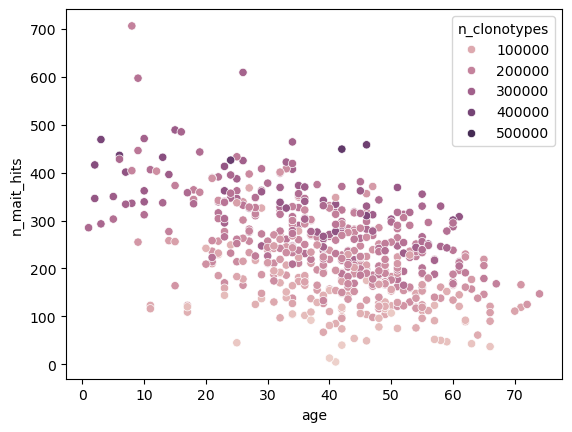

In [29]:
sns.scatterplot(
    table.drop(pl.selectors.by_dtype(pl.List)), x="age", y="n_mait_hits", hue="n_clonotypes"
)

In [49]:
table

repertoire_id,source_files,patient_id,n_clonotypes,n_filtered_clonotypes,total_duplicates,total_mait_duplicates,median_mait_duplicates,mean_mait_duplicates,n_mait_hits,breadth,patient_repertoires,n_repertoires,age,sex,ethnicity,cmv_status,A,B,C,DRB1,DPA1,DPB1,DQA1,DQB1
str,list[str],str,i64,i64,i64,i64,f64,f64,u32,f64,list[str],i64,i64,str,str,bool,list[str],list[str],list[str],list[str],list[str],list[str],list[str],list[str]
"""Keck0001""","[""Keck0001_MC1.tsv""]","""Keck0001""",98381,9164,160828,254,1.0,1.649351,154,-6.453188,"[""Keck0001""]",1,null,null,null,null,null,null,null,null,null,null,null,null
"""Keck0002""","[""Keck0002_MC1.tsv""]","""Keck0002""",85974,8030,179817,472,1.0,3.658915,129,-6.494277,"[""Keck0002""]",1,null,null,null,null,null,null,null,null,null,null,null,null
"""Keck0003""","[""Keck0003_MC1.tsv""]","""Keck0003""",187077,12100,279447,1818,1.0,6.247423,291,-6.462527,"[""Keck0003""]",1,null,null,null,null,null,null,null,null,null,null,null,null
"""Keck0004""","[""Keck0004_MC1.tsv""]","""Keck0004""",119068,9199,185015,326,1.0,1.697917,192,-6.424768,"[""Keck0004""]",1,null,null,null,null,null,null,null,null,null,null,null,null
"""Keck0005""","[""Keck0005_MC1.tsv""]","""Keck0005""",135267,10997,189668,354,1.0,1.934426,183,-6.600078,"[""Keck0005""]",1,null,null,null,null,null,null,null,null,null,null,null,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""P00663""","[""P00663.tsv""]","""P00663""",184770,13205,362090,909,1.0,5.164773,176,-6.950723,"[""P00663""]",1,null,null,"""Unknown Ethnicity""",null,"[""2902"", ""0201""]","[""4403"", ""0702""]","[""1601"", ""0702""]","[""1501"", ""0701""]","[""0103""]","[""0401""]","[""0102"", ""0201""]","[""0602"", ""0202""]"
"""P00665""","[""P00665.tsv""]","""P00665""",47601,5600,117861,86,1.0,1.653846,52,-6.800338,"[""P00665""]",1,57,"""Female""","""Unknown Ethnicity""",false,"[""0101"", ""0201""]","[""5101"", ""5701""]","[""1502"", ""0701""]","[""0901"", ""1302""]","[""0103""]","[""0401"", ""0301""]","[""0102"", ""0302""]","[""0604"", ""0303""]"
"""P00666""","[""P00666.tsv""]","""P00666""",57508,7759,76837,47,1.0,1.146341,41,-7.222027,"[""P00666""]",1,null,null,"""Unknown Ethnicity""",null,"[""0101""]","[""1302"", ""4403""]","[""0602"", ""0401""]","[""1302"", ""0701""]","[""0201"", ""0103""]","[""0401"", ""1301""]","[""0102"", ""0201""]","[""0609"", ""0202""]"


<Axes: xlabel='age', ylabel='hmm'>

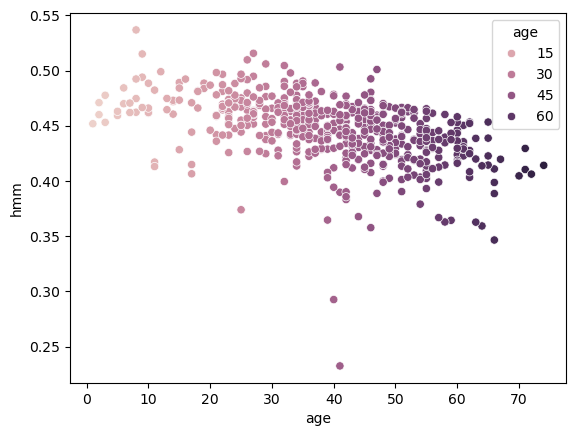

In [52]:
sns.scatterplot(
    table.drop(pl.selectors.by_dtype(pl.List)).with_columns(
        hmm = pl.col('n_mait_hits').log(2) / pl.col("n_clonotypes").add(1).log(2)
    ), x="age", y="hmm", hue="age"
)

<Axes: xlabel='age', ylabel='total_mait_duplicates'>

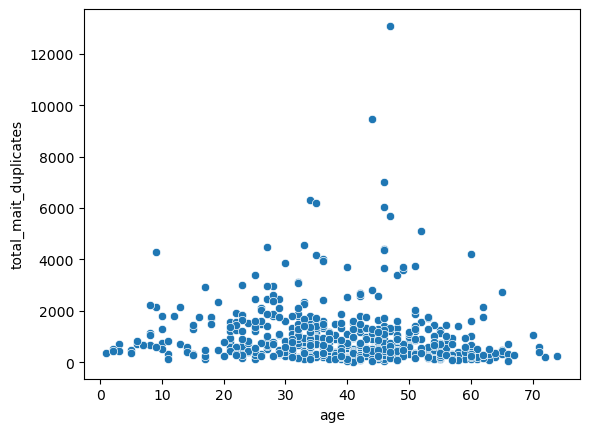

In [26]:
sns.scatterplot(
    table.drop(pl.selectors.by_dtype(pl.List)), x="age", y="total_mait_duplicates"
)

<Axes: xlabel='age', ylabel='median_mait_duplicates'>

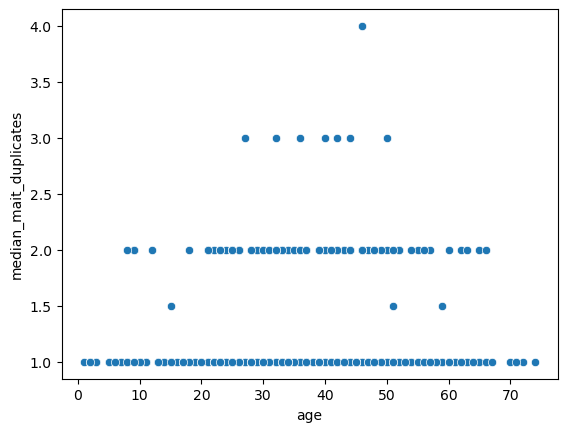

In [27]:
sns.scatterplot(
    table.drop(pl.selectors.by_dtype(pl.List)), x="age", y="median_mait_duplicates"
)

In [3]:
from tcr_io.ingestion import DatasetIngester

In [4]:
from tcr_io.mappers import RegexMapper
from pathlib import Path
import polars as pl

In [11]:
ds = TcrDataset(
    "/data/current/tcrio_db/emerson_2017"
)

In [12]:
from tcr_io.operations import ECOClusterHits

In [13]:
ds.run_operation(ECOClusterHits())

Matching repertoires to CMV ecocluster:   0%|          | 0/786 [00:00<?, ?it/s]

Matching repertoires to CMV ecocluster: 100%|██████████| 786/786 [00:20<00:00, 38.11it/s]

Writing DataFrame to /data/current/tcrio_db/emerson_2017/meta/repertoire/ecocluster_hits.parquet


In [11]:
from tcr_io.operations.base import BaseOperation, OperationResults

In [21]:
from tcr_io.expressions import to_imgt

In [31]:
eco_df.lazy()

In [ ]:
eco_matches = []

for repertoire_id, df in ds.iter_repertoires(progress_bar=True, progress_desc="Matching repertoires to CMV ecocluster"):
    eco_m = df.with_columns(
        pl.col("v_call").str.extract(r"(.*)\*\d{2}").alias("v_gene"),
        pl.col("j_call").str.extract(r"(.*)\*\d{2}").alias("j_gene"),   
    ).join(
        eco_df.select(["v_gene", "j_gene", "junction_aa", "hla_cocluster", "eco_id"]).lazy(),
        on=["v_gene", "j_gene", "junction_aa"],
        how="inner"
    ).select(
        pl.lit(repertoire_id).alias("repertoire_id"),
        pl.sum("duplicate_count").alias("total_cmv_duplicates"),
        pl.median("duplicate_count").alias("median_duplicates").fill_null(0),
        pl.mean("duplicate_count").alias("mean_duplicates").fill_null(0),
        pl.len().alias("n_hits"),
        pl.n_unique("eco_id").alias("n_unique_ecoclusters"),
        pl.col("hla_cocluster").n_unique().alias("n_unique_hla_coclusters"),
    ).collect()

    eco_matches.append(eco_m)


eco_matches = ds.repertoire_meta.select("repertoire_id", "n_clonotypes", "total_duplicates").join(
    pl.concat(eco_matches),
    on="repertoire_id",
    how="left"
).with_columns(
    breadth = pl.col("n_clonotypes").add(1).log() - pl.col("n_hits").add(1).log(),
)

Matching repertoires to CMV ecocluster:   5%|▍         | 100/2072 [00:02<00:41, 47.53it/s]


In [70]:
pl.concat(eco_matches)

repertoire_id,total_cmv_duplicates,median_duplicates,mean_duplicates,n_hits,n_unique_ecoclusters,n_unique_hla_coclusters
str,i64,f64,f64,u32,u32,u32
"""67a2aa4306b40cb07c7a6b2e""",204,1.0,1.942857,105,91,35
"""67a2aa4406b40cb07c7a6b2f""",64,1.0,1.391304,46,46,28
"""67a2aa4406b40cb07c7a6b30""",77,1.0,1.425926,54,51,36
"""67a2aa4506b40cb07c7a6b31""",118,1.0,1.594595,74,62,28
"""67a2aa4506b40cb07c7a6b32""",246,1.0,2.0,123,111,38
…,…,…,…,…,…,…
"""67a2aa6606b40cb07c7a6b8e""",59,1.0,1.134615,52,52,31
"""67a2aa6606b40cb07c7a6b8f""",160,1.0,1.509434,106,102,38
"""67a2aa6706b40cb07c7a6b90""",30,1.0,1.25,24,23,18


SchemaError: type Int64 is incompatible with expected type String

In [ ]:
eco_matches

repertoire_id,n_clonotypes,total_duplicates,total_cmv_duplicates,median_duplicates,mean_duplicates,n_hits,n_unique_ecoclusters,n_unique_hla_coclusters,breadth,depth
str,i64,i64,i64,f64,f64,u32,u32,u32,f64,f64
"""67a2aa4306b40cb07c7a6b2e""",134947,246116,204,1.0,1.942857,105,91,35,7.149206,7.090552
"""67a2aa4406b40cb07c7a6b2f""",110882,238993,64,1.0,1.391304,46,46,28,7.766083,8.209806
"""67a2aa4406b40cb07c7a6b30""",89590,165850,77,1.0,1.425926,54,51,36,7.395677,7.662136
"""67a2aa4506b40cb07c7a6b31""",63361,114782,118,1.0,1.594595,74,62,28,6.739131,6.871675
"""67a2aa4506b40cb07c7a6b32""",109546,209375,246,1.0,2.0,123,111,38,6.783827,6.742499
…,…,…,…,…,…,…,…,…,…,…
"""67a3d2785c92809cf36a9bfd""",101484,183412,null,null,null,null,null,null,null,null
"""67a3d2785c92809cf36a9bfe""",64290,118612,null,null,null,null,null,null,null,null
"""67a3d2795c92809cf36a9bff""",78368,323613,null,null,null,null,null,null,null,null


In [55]:
eco_m

total_duplicates,median_duplicates,mean_duplicates,n_hits,n_unique_ecoclusters,n_unique_hla_coclusters
i64,f64,f64,u32,u32,u32
204,1.0,1.942857,105,91,35


In [44]:
heads_tab_dir = ds.db_dir / "temp/heads_tab"
heads_tab_dir.mkdir(exist_ok=True, parents=True)

pl.scan_parquet(head_dir).select(["v_gene", "j_gene", junction_col, "repertoire_id"]).sink_parquet(
    pl.PartitionBy(heads_tab_dir, key=["v_gene", "j_gene"])
)

In [45]:
from tqdm import tqdm

In [46]:
total_dirs = sum(1 for _ in heads_tab_dir.glob("*/*"))

In [58]:
progress_bar = tqdm(total=total_dirs, desc="Finding shared clones")
shared_clns_list = []
for v in heads_tab_dir.iterdir():
    for j in v.iterdir():
        shared_clns = pl.scan_parquet(j).group_by(["v_gene", "j_gene", junction_col]).agg(
            pl.len().alias("count")
        ).filter(pl.col("count") > 1).collect(engine="streaming")
        shared_clns_list.append(shared_clns)
        progress_bar.update(1)

Finding shared clones: 100%|██████████| 585/585 [03:22<00:00,  2.89it/s] 


In [59]:
shared_clns_list = pl.concat(shared_clns_list).sort("count", descending=True).with_row_index("clone_id")

In [99]:
overlap = pl.scan_parquet(
    head_dir
).join(
    shared_clns_list.lazy(),
    on= ["v_gene", "j_gene", junction_col],
    how="inner"
)

overlap = overlap.join(
    overlap, on="clone_id", how="inner"
).filter(
    pl.col("repertoire_id") < pl.col("repertoire_id_right")
).group_by(["repertoire_id", "repertoire_id_right"]).agg(
    pl.len().alias("n_overlap"),
    pl.corr(pl.col("duplicate_count"), pl.col("duplicate_count_right"), method="pearson").fill_nan(0).alias("pearson_corr"),
    pl.corr(pl.col("duplicate_count"), pl.col("duplicate_count_right"), method="spearman").fill_nan(0).alias("spearman_corr"),
).collect(engine="streaming")

In [109]:
o = ds.repertoire_meta.select(["repertoire_id", "patient_id", "n_filtered_clonotypes"]).with_columns(join=pl.lit(True))

overlap_overview = o.join(o, on="join", how="full").filter(pl.col("repertoire_id") < pl.col("repertoire_id_right")).drop(["join", "join_right"]).join(
    overlap, on=["repertoire_id", "repertoire_id_right"], how="left"
).with_columns(
    pl.col("n_overlap").fill_null(0),
    pl.col("pearson_corr").fill_null(0),
    pl.col("spearman_corr").fill_null(0),
    pl.col("patient_id").eq(pl.col("patient_id_right")).alias("same_patient")
).sort(
    "n_overlap", descending=True
)

In [113]:
threshold_sus_overlap = 40 # different patient, above this threshold, the overlap is suspicious 
threshold_sus_overlap_absence = 20 # same patient, below this threshold, the absence of overlap is suspicious

In [118]:
overlap_overview = overlap_overview.with_columns(
    flag_sus_overlap = (~pl.col("same_patient")).and_(pl.col("n_overlap")>threshold_sus_overlap),
    flag_sus_overlap_absence = pl.col("same_patient").and_(pl.col("n_overlap")<threshold_sus_overlap_absence)
)

In [ ]:
overlap_overview.select(
    pl.len().alias("total_pairs"),
    pl.col("flag_sus_overlap").sum().alias("sus_overlap"),
    pl.col("flag_sus_overlap_absence").sum().alias("sus_overlap_absence")
).with_columns(
    n_repertoires = ds.repertoire_meta.height
)

total_pairs,sus_overlap,sus_overlap_absence,n_repertoires
u32,u32,u32,i32
4163055,411,0,2886


In [ ]:
import igraph as ig
from scipy.sparse import coo_array 
import networkx as nx

edges = matches_scores.filter(
    # pl.col("timepoint") != pl.col("timepoint_right")
).filter(
    #((pl.col("n_matches")> 10) & (pl.col("pearson_correlation")>0)) | 
    ((pl.col("n_matches")>20) & (pl.col("pearson_correlation")>=0.1))
).select(["repertoire_id", "repertoire_id_right", "n_matches", "node_id", "node_id_right", "pearson_correlation"])

n_nodes = gittel_df.height

node_1, node_2, weights = edges.select(["node_id", "node_id_right", "pearson_correlation"]).to_numpy().T

A = coo_array((weights, (node_1, node_2)), shape=(n_nodes, n_nodes))
A = A + A.T
G = nx.Graph(A)
# connected_comps = list(nx.weakly_connected_components(G.to_directed()))
connected_comps = list(nx.connected_components(G))

In [1]:
import plotly.express as px

px.scatter(
    overlap,
    x="spearman_corr",
    y="n_overlap",
    color="same_patient",
    hover_data=["repertoire_id", "repertoire_id_right"]
)

NameError: name 'overlap' is not defined

In [ ]:
overlap = clns_s.lazy().join(
    clns_s.lazy(),
    on="clone_id"
).group_by(["repertoire_id", "repertoire_id_right"]).agg(
    pl.len(),
    pl.corr(pl.col("duplicate_count"), pl.col("duplicate_count_right"), method="spearman").fill_nan(0).alias("spearman_corr"),
    pl.corr(pl.col("duplicate_count"), pl.col("duplicate_count_right"), method="pearson").fill_nan(0).alias("pearson_corr"),
).filter(
    pl.col("repertoire_id") < pl.col("repertoire_id_right")
).collect(engine="streaming")



overlap = overlap.join(
    rep_info, on="repertoire_id"
).join(
    rep_info.rename({"repertoire_id": "repertoire_id_right", "clonotype_count": "clonotype_count_right"}), on="repertoire_id_right"
).with_columns(
    (pl.col("len") / pl.min_horizontal(["clonotype_count", "clonotype_count_right"])).alias("overlap_coefficient"),
    pl.col("len").alias("n_clonotypes"),
    (pl.col("patient_id") == pl.col("patient_id_right")).alias("same_patient")
).sort("overlap_coefficient", descending=True)

In [26]:
shared_clns.collect(engine="streaming")

clone_id,v_call,junction,j_call,count
u32,str,str,str,u32
0,"""TRBV6-4*01""","""tgtgccagcagtgacagggacaccggggag…","""TRBJ2-2*01""",323
1,"""TRBV6-4*01""","""tgtgccagcagtgactctagcgggagcaca…","""TRBJ2-3*01""",190
2,"""TRBV6-4*01""","""tgtgccagcagtgactctagcgggggggcc…","""TRBJ2-1*01""",173
3,"""TRBV6-4*01""","""tgtgccagcagtgggactagcgggagcaca…","""TRBJ2-3*01""",173
4,"""TRBV6-4*01""","""tgtgccagcagtgacagctctggggccaac…","""TRBJ2-6*01""",165
…,…,…,…,…
44920,"""TRBV25-1*01""","""tgtgccagcagtgaacggggggcggagaca…","""TRBJ1-6*02""",2
44921,"""TRBV30*01""","""tgtgcctggagtgtggggacagggggcggg…","""TRBJ1-2*01""",2
44922,"""TRBV6-1*01""","""tgtgccagcagtggggactacaacaatgag…","""TRBJ2-1*01""",2


In [ ]:
h

In [ ]:

top_clns = pl.collect_all([df.head(TOP_N).collect() for _,df in ds.iter_repertoires()])

AttributeError: 'DataFrame' object has no attribute '_ldf'

In [28]:
pl.scan_parquet(ds.db_dir/"tabulated/v_gene=TRBV7-2").collect()

repertoire_id,junction,v_call,junction_aa,j_call,duplicate_count,filter_pass,v_gene,j_gene
str,str,str,str,str,i64,bool,str,str
"""03845000012337""","""tgtgccagcagcccgcgacggaacactgaa…","""TRBV7-2*01""","""CASSPRRNTEAFF""","""TRBJ1-1*01""",316,true,"""TRBV7-2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagctggaagaggggtgagaac…","""TRBV7-2*01""","""CASSWKRGENTEAFF""","""TRBJ1-1*01""",91,true,"""TRBV7-2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagcttattaagtaggagtaac…","""TRBV7-2*01""","""CASSLLSRSNTEAFF""","""TRBJ1-1*01""",18,true,"""TRBV7-2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagctcccaaccagtgaacact…","""TRBV7-2*01""","""CASSSQPVNTEAFF""","""TRBJ1-1*01""",17,true,"""TRBV7-2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagcttagtgggacaaaggaac…","""TRBV7-2*01""","""CASSLVGQRNTEAFF""","""TRBJ1-1*01""",15,true,"""TRBV7-2""","""TRBJ1-1"""
…,…,…,…,…,…,…,…,…
"""8003623352""","""tgtgccagcagctccacagggcccgagcag…","""TRBV7-2*01""","""CASSSTGPEQYF""","""TRBJ2-7*01""",1,true,"""TRBV7-2""","""TRBJ2-7"""
"""8003623352""","""tgtgccagcagcccgcgagggggcagccgg…","""TRBV7-2*01""","""CASSPRGGSRTYEQYF""","""TRBJ2-7*01""",1,true,"""TRBV7-2""","""TRBJ2-7"""
"""8003623352""","""tgtgccagcagccactacaacagggttagc…","""TRBV7-2*01""","""CASSHYNRVSSYEQYF""","""TRBJ2-7*01""",1,true,"""TRBV7-2""","""TRBJ2-7"""


In [21]:
tab_dir = ds.db_dir / "tabulated"

In [25]:
ds.repertoire_meta

repertoire_id,source_files,patient_id,n_clonotypes,n_filtered_clonotypes,total_duplicates
str,list[str],str,i64,i64,i64
"""03845000012337""","[""03845000012337_TCRB.tsv""]","""03845000012337""",264597,31039,785805
"""03845000012997""","[""03845000012997_TCRB.tsv""]","""03845000012997""",225082,21207,521432
"""03845000013182""","[""03845000013182_TCRB.tsv""]","""03845000013182""",445382,50967,1128402
"""03845000013199""","[""03845000013199_TCRB.tsv""]","""03845000013199""",347390,35438,622741
"""03845000014380""","[""03845000014380_TCRB.tsv""]","""03845000014380""",758127,81583,1225570
…,…,…,…,…,…
"""03855000011910""","[""03855000011910_TCRB.tsv""]","""03855000011910""",734189,70638,1152262
"""03855000011911""","[""03855000011911_TCRB.tsv""]","""03855000011911""",593560,71538,995215
"""03855000011912""","[""03855000011912_TCRB.tsv""]","""03855000011912""",282394,31232,653966


In [37]:

for v in tab_dir.iterdir():
    most_common_clns = []
    for j in v.iterdir():
        v_gene = v.name.split("=")[1]
        j_gene = j.name.split("=")[1]
        df = pl.scan_parquet(j).join(
            ds.repertoire_meta.select(["repertoire_id", "patient_id"]).lazy(), on="repertoire_id", how="left"
        ).group_by(
            ["junction_aa"]
        ).agg(
            pl.col("repertoire_id"),
            pl.col("repertoire_id").n_unique().alias("n_repertoires"),
            pl.col("patient_id").n_unique().alias("n_patients"),
        ).sort(
            "n_repertoires", descending=True
        ).with_columns(
            v_gene = pl.lit(v_gene),
            j_gene = pl.lit(j_gene)
        )
        most_common_clns.append(df)

    most_common_clns = pl.concat(
        most_common_clns
    ).collect(
        engine="streaming"
    )

In [38]:
most_common_clns

junction_aa,repertoire_id,n_repertoires,n_patients,v_gene,j_gene
str,list[str],u32,u32,str,str
"""CASSPQGNQPQHF""","[""03855000011746"", ""03855000011855"", ""03855000011874""]",3,3,"""TRBV12-4""","""TRBJ1-5"""
"""CASSFPGQPQHF""","[""03845000012337"", ""03855000011766""]",2,2,"""TRBV12-4""","""TRBJ1-5"""
"""CASSLPPDQPQHF""","[""03855000011771""]",1,1,"""TRBV12-4""","""TRBJ1-5"""
"""CASRQGSDQPQHF""","[""03855000011700""]",1,1,"""TRBV12-4""","""TRBJ1-5"""
"""CASSWTWHQPQHF""","[""03855000011771""]",1,1,"""TRBV12-4""","""TRBJ1-5"""
…,…,…,…,…,…
"""CASRTTGTNIQYF""","[""03855000011873""]",1,1,"""TRBV12-4""","""TRBJ2-4"""
"""CASSLSGANVLTF""","[""03855000011687""]",1,1,"""TRBV12-4""","""TRBJ2-6"""
"""CASTSSGANVLTF""","[""03855000011703""]",1,1,"""TRBV12-4""","""TRBJ2-6"""


In [33]:
v = "TRBV9"

ds.repertoire_dir

PosixPath('/data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/adaptive_gittelman_subset/processed_repertoires')

In [35]:
import polars as pl

In [36]:
vs = pl.scan_parquet(ds.repertoire_dir).filter("filter_pass").select(pl.col("v_call").unique()).with_columns(v_gene = pl.col("v_call").str.extract(r"(.*)\*\d{2}")).collect()
js = pl.scan_parquet(ds.repertoire_dir).filter("filter_pass").select(pl.col("j_call").unique()).with_columns(j_gene = pl.col("j_call").str.extract(r"(.*)\*\d{2}")).collect()

In [38]:
js

j_call,j_gene
str,str
"""TRBJ1-2*01""","""TRBJ1-2"""
"""TRBJ2-5*01""","""TRBJ2-5"""
"""TRBJ1-1*01""","""TRBJ1-1"""
"""TRBJ2-7*01""","""TRBJ2-7"""
"""TRBJ2-6*01""","""TRBJ2-6"""
…,…
"""TRBJ1-6*01""","""TRBJ1-6"""
"""TRBJ2-3*01""","""TRBJ2-3"""
"""TRBJ1-6*02""","""TRBJ1-6"""


In [40]:
# for v_gene, v_alleles in vs.group_by("v_gene").agg(pl.col("v_call")).iter_rows():
#     print(v_gene, v_alleles)

In [42]:
pl.scan_parquet(ds.repertoire_dir).filter("filter_pass").with_columns(
    v_gene = pl.col("v_call").str.extract(r"(.*)\*\d{2}"),
    j_gene = pl.col("j_call").str.extract(r"(.*)\*\d{2}")
).sink_parquet(
    pl.PartitionBy("temp_tabulated_by_vj_call", key=["v_gene", "j_gene"])
)

In [46]:
pl.scan_parquet("temp_tabulated_by_vj_call/v_gene=TRBV2/").collect()

repertoire_id,junction,v_call,junction_aa,j_call,duplicate_count,filter_pass,v_gene,j_gene
str,str,str,str,str,i64,bool,str,str
"""03845000012337""","""tgtgccagagagacgagacagggaggaaca…","""TRBV2*01""","""CARETRQGGTTEAFF""","""TRBJ1-1*01""",717,true,"""TRBV2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagtgcgccggcggctgggaac…","""TRBV2*01""","""CASSAPAAGNTEAFF""","""TRBJ1-1*01""",60,true,"""TRBV2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagtccggacagggatgctgaa…","""TRBV2*01""","""CASSPDRDAEAFF""","""TRBJ1-1*01""",55,true,"""TRBV2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagttacggaaaggggcagaaa…","""TRBV2*01""","""CASSYGKGQKAFF""","""TRBJ1-1*01""",46,true,"""TRBV2""","""TRBJ1-1"""
"""03845000012337""","""tgtgccagcagtaacaaacgccccatgaac…","""TRBV2*01""","""CASSNKRPMNTEAFF""","""TRBJ1-1*01""",44,true,"""TRBV2""","""TRBJ1-1"""
…,…,…,…,…,…,…,…,…
"""03855000011914""","""tgtgccagcagtgatccggcagcctcatac…","""TRBV2*01""","""CASSDPAASYTNEQYF""","""TRBJ2-7*01""",1,true,"""TRBV2""","""TRBJ2-7"""
"""03855000011914""","""tgtgccagcaggggaagaggggcccactac…","""TRBV2*01""","""CASRGRGAHYEQYF""","""TRBJ2-7*01""",1,true,"""TRBV2""","""TRBJ2-7"""
"""03855000011914""","""tgtgccagcagtgaagcagggtttgacgag…","""TRBV2*01""","""CASSEAGFDEQYF""","""TRBJ2-7*01""",1,true,"""TRBV2""","""TRBJ2-7"""


In [28]:
tcrs_with_v = pl.scan_parquet(ds.repertoire_dir).filter("filter_pass").filter(pl.col("v_call").is_in(v_alleles)).with_columns(
    v_gene = pl.lit(v_gene)
)

tcrs_with_vj_list = []
for j_gene, j_alleles in js.group_by("j_gene").agg(pl.col("j_call")).iter_rows():
    tcrs_with_vj = tcrs_with_v.filter(pl.col("j_call").is_in(j_alleles)).with_columns(
        j_gene = pl.lit(j_gene)
    )
    tcrs_with_vj_list.append(tcrs_with_vj)

In [29]:
pl.concat(tcrs_with_vj_list).sink_parquet(pl.PartitionBy(f"result/v_gene={v_gene}", key=["j_gene"]))

In [ ]:
tcrs_with_vj = 

In [ ]:
t

In [15]:
ds.run_operation(
    FilteringReport()
)

Creating filtering summary: 100%|██████████| 348/348 [00:05<00:00, 64.18it/s]


Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490/qc/filter/filter_summary.parquet
Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490/qc/filter/filter_top_invalid_junction_aa.parquet
Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490/qc/filter/filter_top_invalid_v_call.parquet
Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490/qc/filter/filter_top_non_functional_v_call.parquet
Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490/qc/filter/filter_top_invalid_j_call.parquet
Writing DataFrame to /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490/qc/filter/filter_top_non_functional_j_call.parquet


In [20]:
ds.get_operation_result(
    "filtering_report",
    "v_call"
)

v_call,count
str,u32
"""TRBV12-34*01""",151332
"""TRBV6-23*01""",102203
"""TRBV20-1*04_322GA323""",7689
"""TRBV10-3*02_313GCCATCAGTGAGTC3…",6991
"""TRBV14*02_322CAAGA326""",1366
…,…
"""TRBV30*01_G298A""",42
"""TRBV29-1*03_C315T""",27
"""TRBV21-1*01_C199T""",13


In [21]:
ds.operations

[OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:33:53.507864', duration_s=0.004152774810791016, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:34:01.689334', duration_s=0.0045375823974609375, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:43:36.233919', duration_s=0.00391387939453125, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.3', ran_at='2026-05-26 23:03:48.475744', duration_s=0.0055119991302490234, status='success', error=None, description='Test operation that 

In [13]:
from time import sleep

In [13]:
op = TestNullOperation()

In [24]:
from tcr_io.filters import Filterer, get_filter_summary

In [25]:
f = Filterer(return_individual_filters=True)

In [26]:
from collections import defaultdict

In [27]:
from tqdm import tqdm

In [50]:
filter_summ.columns

['repertoire_id',
 'not_null_v',
 'not_null_j',
 'not_null_junction',
 'not_null_junction_aa',
 'valid_junction_aa',
 'v_valid_imgt',
 'v_func_imgt',
 'j_valid_imgt',
 'j_func_imgt',
 'consensus']

In [43]:
filter_summ = []
top_invalid = defaultdict(list)


for rep_id, rep in ds.iter_repertoires(progress_bar=True, progress_desc="Creating filtering summary"):
    filtered = f.run(rep).filter(pl.col("filter_pass").eq(False))
    filtered_filters = filtered.select(pl.col("filters")).collect()

    filter_summ.append(
        get_filter_summary(filtered_filters).with_columns(
            repertoire_id = pl.lit(rep_id)
        )
    )

    top_invalid["invalid_junction_aa"].append(
        filtered.filter(
            pl.col("filters").struct.field("valid_junction_aa").eq(False)
        ).group_by("junction_aa").agg(pl.len()).sort("len", descending=True).collect()
    )

    top_invalid["invalid_v_call"].append(
        filtered.filter(
            pl.col("filters").struct.field("v_valid_imgt").eq(False)
        ).group_by("v_call").agg(pl.len()).sort("len", descending=True).collect()
    )

    top_invalid["non_functional_v_call"].append(
        filtered.filter(
            pl.col("filters").struct.field("v_valid_imgt").eq(True)
            & pl.col("filters").struct.field("v_func_imgt").eq(False)
        ).group_by("v_call").agg(pl.len()).sort("len", descending=True).collect()
    )

    top_invalid["invalid_j_call"].append(
        filtered.filter(
            pl.col("filters").struct.field("j_valid_imgt").eq(False)
        ).group_by("j_call").agg(pl.len()).sort("len", descending=True).collect()
    )

    top_invalid["non_functional_j_call"].append(
        filtered.filter(
            pl.col("filters").struct.field("j_valid_imgt").eq(True)
            & pl.col("filters").struct.field("j_func_imgt").eq(False)
        ).group_by("j_call").agg(pl.len()).sort("len", descending=True).collect()
    )

filter_summ = pl.concat(filter_summ).pivot(
    on = "filter",
    values = "exclusions",
    index="repertoire_id"   
)

top_invalid_res = dict()
for k,reps in top_invalid.items():
    df = pl.concat(reps)
    top_invalid_res[k] = df.group_by(df.columns[0]).agg(pl.col("len").sum()).sort("len", descending=True).rename({"len":"count"})

Creating filtering summary: 100%|██████████| 348/348 [00:05<00:00, 64.89it/s]


In [48]:
for reason, df in top_invalid_res.items():
    print(f"Top {reason}:")
    print(df.head(10))


Top invalid_junction_aa:
shape: (10, 2)
┌─────────────────────┬───────┐
│ junction_aa         ┆ count │
│ ---                 ┆ ---   │
│ str                 ┆ u32   │
╞═════════════════════╪═══════╡
│ CASSLMDRGQFVVATP    ┆ 172   │
│ CASS                ┆ 156   │
│ CASSL               ┆ 130   │
│ CASSSHSGGLPLLQ*AVL  ┆ 122   │
│ CASSS               ┆ 116   │
│ CASS*RCGRLFQETQYF   ┆ 101   │
│ CASSY               ┆ 100   │
│ CASSP               ┆ 85    │
│ CASSRPPRDTLGSMGSPSI ┆ 80    │
│ CSD*AEKRERNTEAFF    ┆ 73    │
└─────────────────────┴───────┘
Top invalid_v_call:
shape: (10, 2)
┌─────────────────────────────────┬────────┐
│ v_call                          ┆ count  │
│ ---                             ┆ ---    │
│ str                             ┆ u32    │
╞═════════════════════════════════╪════════╡
│ TRBV12-34*01                    ┆ 151332 │
│ TRBV6-23*01                     ┆ 102203 │
│ TRBV20-1*04_322GA323            ┆ 7689   │
│ TRBV10-3*02_313GCCATCAGTGAGTC3… ┆ 6991   │
│ TRBV14

In [41]:
top_invalid_res["invalid_v_call"].head(20)

v_call,len
str,u32
"""TRBV12-34*01""",151332
"""TRBV6-23*01""",102203
"""TRBV20-1*04_322GA323""",7689
"""TRBV10-3*02_313GCCATCAGTGAGTC3…",6991
"""TRBV14*02_322CAAGA326""",1366
…,…
"""TRBV30*01_G298A""",42
"""TRBV29-1*03_C315T""",27
"""TRBV21-1*01_C199T""",13


In [26]:
ds.repertoire_meta.join(
    filter_summ, on="repertoire_id", how="left"
)

repertoire_id,source_files,patient_id,n_clonotypes,n_filtered_clonotypes,total_duplicates,not_null_v,not_null_j,not_null_junction,not_null_junction_aa,valid_junction_aa,v_valid_imgt,v_func_imgt,j_valid_imgt,j_func_imgt,consensus
str,list[str],str,i64,i64,i64,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
"""healthy10""","[""PRJEB33490_TRB_healthy10_PRJEB33490_TRB.tsv""]","""healthy10""",16630,5977,55381,0,0,0,0,4207,1589,181,0,0,0
"""healthy11""","[""PRJEB33490_TRB_healthy11_PRJEB33490_TRB.tsv""]","""healthy11""",5596,2567,23458,0,0,0,0,1582,915,70,0,0,0
"""healthy12""","[""PRJEB33490_TRB_healthy12_PRJEB33490_TRB.tsv""]","""healthy12""",9476,3328,33339,0,0,0,0,1935,1344,49,0,0,0
"""healthy13""","[""PRJEB33490_TRB_healthy13_PRJEB33490_TRB.tsv""]","""healthy13""",14763,4936,49784,0,0,0,0,2759,2083,94,0,0,0
"""healthy14""","[""PRJEB33490_TRB_healthy14_PRJEB33490_TRB.tsv""]","""healthy14""",7592,2469,34426,0,0,0,0,1437,969,63,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""solid_cancer97""","[""PRJEB33490_TRB_solid_cancer97_PRJEB33490_TRB.tsv""]","""solid_cancer97""",1570,701,7749,0,0,0,0,356,254,33,0,58,0
"""solid_cancer98""","[""PRJEB33490_TRB_solid_cancer98_PRJEB33490_TRB.tsv""]","""solid_cancer98""",1407,417,7893,0,0,0,0,262,150,5,0,0,0
"""solid_cancer99""","[""PRJEB33490_TRB_solid_cancer99_PRJEB33490_TRB.tsv""]","""solid_cancer99""",633,347,3461,0,0,0,0,187,158,2,0,0,0


In [51]:
from collections import defaultdict

In [14]:
ds.get_operation_result("test_null_operation", "filter_pass")

/data/current/projects/tcrio/tcrio/tcr_io/dataset.py:143: UserWarning: Operation test_null_operation (version 0.4.1) failed. Skipping.
  warnings.warn(f"Operation {op.operation_name} (version {op.version}) failed. Skipping.")


repertoire_id,filter_pass_pct,yolocolumn
str,f64,str
"""healthy10""",0.735613,"""yolo"""
"""healthy11""",0.685532,"""yolo"""
"""healthy12""",0.740081,"""yolo"""
"""healthy13""",0.749429,"""yolo"""
"""healthy14""",0.754597,"""yolo"""
…,…,…
"""solid_cancer97""",0.691325,"""yolo"""
"""solid_cancer98""",0.771382,"""yolo"""
"""solid_cancer99""",0.645918,"""yolo"""


In [15]:
ds.operations

[OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:33:53.507864', duration_s=0.004152774810791016, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:34:01.689334', duration_s=0.0045375823974609375, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:43:36.233919', duration_s=0.00391387939453125, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.3', ran_at='2026-05-26 23:03:48.475744', duration_s=0.0055119991302490234, status='success', error=None, description='Test operation that 

In [20]:
pl.scan_parquet(ds.repertoire_dir).filter(
    pl.col("filter_pass")
).collect()

repertoire_id,junction,v_call,junction_aa,j_call,duplicate_count,filter_pass
str,str,str,str,str,i64,bool
"""healthy1""","""tgtgccaccagcagagtgagcagccaagag…","""TRBV15*02""","""CATSRVSSQETQYF""","""TRBJ2-5*01""",844,true
"""healthy1""","""tgtgccagtagtaccgggacggggatcaca…","""TRBV19*01""","""CASSTGTGITDTQYF""","""TRBJ2-3*01""",436,true
"""healthy1""","""tgtgccagcagcttagcggagggactggga…","""TRBV11-1*01""","""CASSLAEGLGYEQYF""","""TRBJ2-7*01""",371,true
"""healthy1""","""tgtgccaccagcaggactagcgcccaagag…","""TRBV15*02""","""CATSRTSAQETQYF""","""TRBJ2-5*01""",277,true
"""healthy1""","""tgtgccagcagcttgacagatacgcagtat…","""TRBV5-6*01""","""CASSLTDTQYF""","""TRBJ2-3*01""",242,true
…,…,…,…,…,…,…
"""solid_cancer99""","""tgtgccagcagcccccccgggactagcgga…","""TRBV7-6*01""","""CASSPPGTSGRYAVF""","""TRBJ2-3*01""",1,true
"""solid_cancer99""","""tgcagtgatagagatatggctagcgggccc…","""TRBV20-1*01""","""CSDRDMASGPYNEQFF""","""TRBJ2-1*01""",1,true
"""solid_cancer99""","""tgtgccgacagcccggaccgctatggctac…","""TRBV6-5*01""","""CADSPDRYGYTF""","""TRBJ1-2*01""",1,true


In [16]:
ds.get_operation_result("test_null_operation")

repertoire_id,filter_pass_pct,yolocolumn
str,f64,str
"""healthy10""",0.735613,"""yolo"""
"""healthy11""",0.685532,"""yolo"""
"""healthy12""",0.740081,"""yolo"""
"""healthy13""",0.749429,"""yolo"""
"""healthy14""",0.754597,"""yolo"""
…,…,…
"""solid_cancer97""",0.691325,"""yolo"""
"""solid_cancer98""",0.771382,"""yolo"""
"""solid_cancer99""",0.645918,"""yolo"""


In [20]:
from tcr_io.operations.base import OperationMeta

In [21]:
import json

In [22]:
operations = []
with open(ds.db_dir/"meta/operations.json", "r") as f:
    for line in f.readlines():
        json_obj = json.loads(line)
        operations.append(OperationMeta(**json_obj))

In [29]:
operations

[OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:33:53.507864', duration_s=0.004152774810791016, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:34:01.689334', duration_s=0.0045375823974609375, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.1', ran_at='2026-05-26 22:43:36.233919', duration_s=0.00391387939453125, status='success', error=None, description='Test operation that creates some empty output', outputs=['qc/filter_pass.parquet']),
 OperationMeta(operation_name='test_null_operation', version='0.3', ran_at='2026-05-26 23:03:48.475744', duration_s=0.0055119991302490234, status='success', error=None, description='Test operation that 

In [30]:
ds.get_operation_result(op.name)

repertoire_id,filter_pass_pct,yolocolumn
str,f64,str
"""healthy10""",0.735613,"""yolo"""
"""healthy11""",0.685532,"""yolo"""
"""healthy12""",0.740081,"""yolo"""
"""healthy13""",0.749429,"""yolo"""
"""healthy14""",0.754597,"""yolo"""
…,…,…
"""solid_cancer97""",0.691325,"""yolo"""
"""solid_cancer98""",0.771382,"""yolo"""
"""solid_cancer99""",0.645918,"""yolo"""


In [70]:
ds.generation_meta

{'dataset_name': 'PRJEB33490',
 'created_on': datetime.date(2026, 5, 18),
 'source': '/data/current/datasets/to_process/PREBJ33490/*.tsv',
 'reader': "WeirdBpAirrReader(name=airr, col_map={'junction': 'junction', 'junction_aa': 'junction_aa', 'v_call': 'v_call', 'j_call': 'j_call', ('umi_count', 'duplicate_count'): 'duplicate_count'})",
 'repertoire_mapper': 'RegexMapper(pattern=((solid_cancer|healthy|hematological_cancer)\\d+), group=1)',
 'patient_mapper': 'RegexMapper(pattern=((solid_cancer|healthy|hematological_cancer)\\d+), group=1)'}

In [72]:
import datetime

In [ ]:
di = DatasetIngester(
    db_dir  ="/data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp",
    db_name = "test_dataset3",
    repertoire_mapper=RegexMapper(r"(Sample\_\d+)", group=1),
    patient_mapper=RegexMapper(r"(Sample\_\d)", group=1),
    # reader = ReaderFactory(),
    publication_ids = ["PRJNA123456", "10.1234/example.doi"]
)

In [71]:
di.run( "/data/current/datasets/to_process/PRJNA1152888/*.tsv")

FileExistsError: Dataset already exists: /data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp/PRJEB33490.

In [5]:
from tcr_io.dataset import TcrDataset

In [6]:
ds = TcrDataset(
    db_dir=Path("/data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp"),
    db_name="test_dataset3"
)

In [7]:
ds

TcrDataset test_dataset3, created_on 2026-05-18, 1214419 clonotypes (33 repertoires, 5 patients).

In [9]:
import polars as pl

In [14]:
ds.generation_meta

{'dataset_name': 'test_dataset3',
 'created_on': datetime.date(2026, 5, 18),
 'source': '/data/current/datasets/to_process/PRJNA1152888/*.tsv',
 'reader': "ReaderFactory, last_resolved_reader=AirrReader(name=airr, col_map={'junction': 'junction', 'junction_aa': 'junction_aa', 'v_call': 'v_call', 'j_call': 'j_call', ('umi_count', 'duplicate_count'): 'duplicate_count'})",
 'repertoire_mapper': 'RegexMapper(pattern=(Sample\\_\\d+), group=1)',
 'patient_mapper': 'RegexMapper(pattern=(Sample\\_\\d), group=1)'}

In [8]:
ds.generation_meta.collect()

dataset_name,created_on,source,reader,repertoire_mapper,patient_mapper
str,date,str,str,str,str
"""test_dataset3""",2026-05-18,"""/data/current/datasets/to_proc…","""ReaderFactory, last_resolved_r…","""RegexMapper(pattern=(Sample\_\…","""RegexMapper(pattern=(Sample\_\…"


In [8]:
import polars as pl

In [9]:
from tcr_io.schema import GENERATION_META

In [13]:
pl.read_ndjson(di.db_dir/"meta"/"generation.json").cast(GENERATION_META)[0, "reader"]

"ReaderFactory, last_resolved_reader=AirrReader(name=airr, col_map={'junction': 'junction', 'junction_aa': 'junction_aa', 'v_call': 'v_call', 'j_call': 'j_call', ('umi_count', 'duplicate_count'): 'duplicate_count'})"

In [ ]:
import polars as pla

In [2]:
from tcr_io.schema import REPERTOIRE, REPERTOIRE_META, PATIENT_META, GENERATION_META

In [3]:
from tcr_io.readers import MixcrReader, ReaderFactory
from pathlib import Path
import polars as pl

In [ ]:
data_path =

In [5]:
rf = ReaderFactory()

In [6]:
import pandas as pd

In [7]:
from tcr_io.readers import ReaderFactory

In [ ]:
from collections import defaultdict
from tcr_io.mappers import BaseMapper
from tcr_io.readers import BaseReader, ReaderFactory
from typing import List
import logging
from tcr_io.dataset import TcrDataset
from tqdm import tqdm



logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

def _process_path_wildcards(f: Path|str) -> List[Path]:
    path = Path(f)
    if path.is_file():
        return [path]
    elif path.is_dir():
        return list(path.iterdir())
    elif "*" in f:
        return list(path.parent.glob(path.name))
    else:
        raise ValueError(f"Path {f} is not a file, directory, or wildcard pattern.")

class DatasetIngester:

    def __init__(
        self,
        # raw_dir: str | Path,
        db_dir: str | Path,
        db_name: str,
        repertoire_mapper: BaseMapper,
        patient_mapper: BaseMapper,
        reader: BaseReader | ReaderFactory | None = None,
        publication_ids : List[str] | None = None,
        overwrite: bool = False,
        # repertoire_metadata: Optional[pl.DataFrame] = None,
        # overwrite: bool = False,
    ):
        self.db_dir = Path(db_dir) / db_name
        self.reader = reader or ReaderFactory()
        self.repertoire_mapper = repertoire_mapper
        self.patient_mapper = patient_mapper
        self.db_name = db_name
        self.publication_ids = publication_ids or []

    def _create_structure(self):
        if self.db_dir.exists():
            raise FileExistsError(
                f"Dataset already exists: {self.db_dir}."
            )

        for subdir in TcrDataset.REQUIRED_DIRS + [TcrDataset.TABULATED_DIR]:
            (self.db_dir / subdir).mkdir(parents=True, exist_ok=True)

        
    def _create_mapping(self, dir:Path|str):

        dir : List[Path] = _process_path_wildcards(dir)

        data, skipped_files = self._resolve_dir(dir)
        repertoires = defaultdict(list)
        repertoires_to_patients = dict()

        for file, repertoire_id, patient_id in data:
            repertoires[repertoire_id].append(file)
            repertoires_to_patients[repertoire_id] = patient_id

        return repertoires, repertoires_to_patients, skipped_files

    def _resolve_dir(self, files: List[Path]):
        data = []
        skipped_files = []
        for file in files:
            if file.is_dir():
                continue    
            try:
                repertoire_id = self.repertoire_mapper.transform(file)
                patient_id = self.patient_mapper.transform(file)
                data.append((file, repertoire_id, patient_id))

            except KeyError as e:
                skipped_files.append(file)

        return data, skipped_files
    
    def process(self, dir:Path|str):
        logger.info(f"Processing dataset {self.db_name} from {dir}...")
        self._create_structure()
        logger.info("Creating mappings...")
        repertoires, repertoires_to_patients, skipped = self._create_mapping(dir)
        logger.info(f"Mapping created. {len(repertoires)} repertoires mapped from {len(set(repertoires_to_patients.values()))} unique patients, {len(skipped)} files skipped.")
        self._process_repertoires(repertoires)
        self._generate_repertoire_metadata(repertoires, repertoires_to_patients).write_parquet(
            self.db_dir / "meta" / "repertoire" / "repertoire.parquet"
        )
        self._generate_patient_metadata(repertoires_to_patients).write_parquet(
            self.db_dir / "meta" / "patient" / "patient.parquet"
        )
        self._generate_publication_metadata(self.publication_ids).write_parquet(
            self.db_dir / "meta" / "publication" / "publication_ids.parquet"
        )
        self._generate_generation_metadata(dir).write_parquet(
            self.db_dir / "meta" / "generation.parquet"
        )
        logger.info("Dataset processing complete.")
    
    def _process_repertoires(self, repertoires):

        for repertoire_id, files in tqdm(repertoires.items(), desc="Reading repertoires"):
            df = self.reader.run(files)
            df = df.with_columns(
                pl.lit(repertoire_id).alias("repertoire_id")
            ).select(REPERTOIRE.keys()).cast(REPERTOIRE)

            repertoire_id_safe = repertoire_id.replace("/", "_")

            df.sink_parquet(self.db_dir/"processed_repertoires"/f"{repertoire_id_safe}.parquet")

    def _generate_repertoire_metadata(self, repertoires, repertoires_to_patients) -> pl.DataFrame:

        df = pl.DataFrame({
            "repertoire_id": repertoires.keys(),
            "source_files": [[f.name for f in files] for files in repertoires.values()],
            "patient_id" : [repertoires_to_patients[rep_id] for rep_id in repertoires.keys()]
        })

        rep_sizes = []

        for f in (self.db_dir/"processed_repertoires").glob("*.parquet"):
            s = pl.scan_parquet(f).select(
                pl.first("repertoire_id"),
                pl.len().alias("n_clonotypes"),
                pl.sum('duplicate_count').alias("total_duplicates")
            )

            rep_sizes.append(s)

        rep_sizes = pl.concat(rep_sizes).collect(engine="streaming")

        df = df.join(rep_sizes, on="repertoire_id", how="left").with_columns(
            pl.col("n_clonotypes").fill_null(0),
            pl.col("total_duplicates").fill_null(0)
        )

        df = df.select(REPERTOIRE_META.keys()).cast(REPERTOIRE_META)

        return df

    def _generate_patient_metadata(self, repertoires_to_patients):

        repertoires_by_patient = defaultdict(list)
        for rep_id, patient_id in repertoires_to_patients.items():
            repertoires_by_patient[patient_id].append(rep_id)
        
        df = pl.DataFrame({
            "patient_id": list(repertoires_by_patient.keys()),
            "patient_repertoires": list(repertoires_by_patient.values()),
            "n_repertoires": [len(repertoires) for repertoires in repertoires_by_patient.values()]
        })

        return df.select(PATIENT_META.keys()).cast(PATIENT_META)
    

    def _generate_publication_metadata(self, publication_ids):
        df = pl.DataFrame({
            "publication_id": publication_ids
        })

        return df.select(PUBLICATION_META.keys()).cast(PUBLICATION_META)
    
    def _generate_generation_metadata(self, data_dir: Path):
        df = pl.DataFrame({
            "dataset_name" : self.db_name,
            "created_on" : pl.now(),
            "source": str(data_dir),
            "reader" : self.reader.__repr__(),
            "repertoire_mapper" : self.repertoire_mapper.__repr__(),
            "patient_mapper" : self.patient_mapper.__repr__(),
        })
        return df.select(GENERATION_META.keys()).cast(GENERATION_META)

        

    def _test_mappers(self, dir:Path|str):
        dir : List[Path] = _process_path_wildcards(dir)
        print("Repertoire mapping : ")
        print("-------------------")
        self.repertoire_mapper.test(dir)
        print("\nPatient mapping : ")
        print("-------------------")
        self.patient_mapper.test(dir)

In [16]:
from tcr_io.mappers import RegexMapper, ChainedMapper, DictMapper

In [12]:
di = DatasetIngester(
    db_dir="/data/current/projects/tcrio/tcrio/test_nbs/tcrdb_temp",
    db_name="test_db12",
    repertoire_mapper=RegexMapper(r"(Sample\_\d+)", group=1),
    patient_mapper=RegexMapper(r"(Sample\_\d)", group=1),
    overwrite=True
)

In [27]:
di.repertoire_mapper

In [13]:
di.process(
    "/data/current/datasets/to_process/PRJNA1152888/*.tsv"
)

Reading repertoires: 100%|██████████| 33/33 [00:00<00:00, 44.21it/s]


In [24]:
pl.scan_parquet(
    di.db_dir/"meta"/"repertoire"/"repertoire.parquet"
).select(
    pl.sum("n_clonotypes"),
    pl.len().alias("n_repertoires"),
    pl.n_unique("patient_id")
).collect()

n_clonotypes,n_repertoires,patient_id
i64,u32,u32
1214419,33,5


In [ ]:
pl.read_parquet(di.db_dir/"meta"/"repertoire"/"repertoire.parquet")

repertoire_id,source_files,patient_id,n_clonotypes,total_duplicates
str,list[str],str,i64,i64
"""Sample_20""","[""PRJNA1152888_TRB_Sample_20_PRJNA1152888_TRB.tsv""]","""Sample_2""",60556,102884
"""Sample_21""","[""PRJNA1152888_TRB_Sample_21_PRJNA1152888_TRB.tsv""]","""Sample_2""",1234,1600
"""Sample_22""","[""PRJNA1152888_TRB_Sample_22_PRJNA1152888_TRB.tsv""]","""Sample_2""",22778,30240
"""Sample_23""","[""PRJNA1152888_TRB_Sample_23_PRJNA1152888_TRB.tsv""]","""Sample_2""",34574,52501
"""Sample_24""","[""PRJNA1152888_TRB_Sample_24_PRJNA1152888_TRB.tsv""]","""Sample_2""",26090,47627
…,…,…,…,…
"""Sample_48""","[""PRJNA1152888_TRB_Sample_48_PRJNA1152888_TRB.tsv""]","""Sample_4""",11685,15237
"""Sample_49""","[""PRJNA1152888_TRB_Sample_49_PRJNA1152888_TRB.tsv""]","""Sample_4""",5471,6546
"""Sample_50""","[""PRJNA1152888_TRB_Sample_50_PRJNA1152888_TRB.tsv""]","""Sample_5""",53814,104458


In [13]:
repertoires, repertoires_to_patients, skipped = di._create_mapping("/data/current/datasets/to_process/PRJNA1152888/*.tsv")

In [20]:
di._generate_repertoire_metadata(repertoires, repertoires_to_patients)

repertoire_id,source_files,patient_id,n_clonotypes,total_duplicates
str,list[str],str,i64,i64
"""Sample_20""","[""PRJNA1152888_TRB_Sample_20_PRJNA1152888_TRB.tsv""]","""Sample_2""",60556,102884
"""Sample_21""","[""PRJNA1152888_TRB_Sample_21_PRJNA1152888_TRB.tsv""]","""Sample_2""",1234,1600
"""Sample_22""","[""PRJNA1152888_TRB_Sample_22_PRJNA1152888_TRB.tsv""]","""Sample_2""",22778,30240
"""Sample_23""","[""PRJNA1152888_TRB_Sample_23_PRJNA1152888_TRB.tsv""]","""Sample_2""",34574,52501
"""Sample_24""","[""PRJNA1152888_TRB_Sample_24_PRJNA1152888_TRB.tsv""]","""Sample_2""",26090,47627
…,…,…,…,…
"""Sample_48""","[""PRJNA1152888_TRB_Sample_48_PRJNA1152888_TRB.tsv""]","""Sample_4""",11685,15237
"""Sample_49""","[""PRJNA1152888_TRB_Sample_49_PRJNA1152888_TRB.tsv""]","""Sample_4""",5471,6546
"""Sample_50""","[""PRJNA1152888_TRB_Sample_50_PRJNA1152888_TRB.tsv""]","""Sample_5""",53814,104458


In [130]:
REP_SCHEMA =  pl.Schema({
    "repertoire_id": pl.Utf8,
    "files": pl.List(pl.Utf8),
    "patient_id": pl.Utf8,
})

In [131]:
rep_df = pl.DataFrame({
    "repertoire_id": repertoires.keys(),
    "files": [[f.name for f in files] for files in repertoires.values()],
    "patient_id" : [repertoires_to_patients[rep_id] for rep_id in repertoires.keys()]
}, schema=REP_SCHEMA)

7.96 ms ± 49.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
ReaderFactory().run(data_path/"PRJNA1152888_TRB_Sample_24_PRJNA1152888_TRB.tsv")

repertoire_id,junction,v_call,junction_aa,j_call,duplicate_count
str,str,str,str,str,i64
"""rep1""","""tgtgccagcagttacagacctggtgacaat…","""TRBV12-4*01""","""CASSYRPGDNEQFF""","""TRBJ2-1*01""",319
"""rep1""","""tgtgccagcacctggtcaggctcggctagc…","""TRBV27*01""","""CASTWSGSASGREDF""","""TRBJ2-3*01""",300
"""rep1""","""tgtgccagcagctataacccgggactaggc…","""TRBV3-1*01""","""CASSYNPGLGYEQYF""","""TRBJ2-7*01""",193
"""rep1""","""tgtgccagcagttatctagcgggcgcgcag…","""TRBV12-4*01""","""CASSYLAGAQAGELFF""","""TRBJ2-2*01""",180
"""rep1""","""tgtgccagcagcttaggaccgggagcgact…","""TRBV7-6*01""","""CASSLGPGATNEKLFF""","""TRBJ1-4*01""",164
…,…,…,…,…,…
"""rep1""","""tgcagtgctagagatctgggcagtaaagag…","""TRBV20-1*05""","""CSARDLGSKEQFF""","""TRBJ2-1*01""",1
"""rep1""","""tgtgccagcaccctcccgggactagcggga…","""TRBV18*01""","""CASTLPGLAGGGEQFF""","""TRBJ2-1*01""",1
"""rep1""","""tgtgccagcagtccccagcgacgcacagat…","""TRBV27*01""","""CASSPQRRTDTQYF""","""TRBJ2-3*01""",1


In [ ]:
REPERTOIRE.

Schema([('repertoire_id', String),
        ('file', String),
        ('junction', String),
        ('v_call', String),
        ('junction_aa', String),
        ('j_call', String),
        ('duplicate_count', Int64)])